# Final Result Draft

This notebook assembles the paper-facing result view discussed in the chat:

- selector taxonomy table,
- attack success / ASR by value selector and sampling strategy,
- defense-based detectability using HDBSCAN, Spectral Signature, and Isolation Forest,

The default focus is the 1% poison-rate setting. Tables and figures below filter out the other poison-rate settings.

In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
from IPython.display import display, Markdown, FileLink

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_ROOT = PROJECT_ROOT / "results" / "experiment 1"
MPLCONFIGDIR = PROJECT_ROOT / "build" / "matplotlib"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import matplotlib.pyplot as plt
import seaborn as sns

from src.analysis.result_catalog import (
    DEFENSE_LABELS,
    VALUE_LABELS,
    add_display_columns,
    load_attack_summaries,
    load_detector_metrics,
    load_detectability_summaries,
    preferred_detector_metrics,
)

pd.set_option("display.max_rows", 400)
pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 240)
sns.set_theme(style="whitegrid", context="notebook")

print("Project root:", PROJECT_ROOT)
print("Results root:", RESULTS_ROOT)

Project root: /Users/falcon/Machine Learning/Defense GMM-Maha
Results root: /Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1


## Analysis Controls

Change these lists if you want to narrow the final draft table. `MAIN_POISON_RATE = 0.01` gives the 1% setting. The displayed tables and figures use this selected poison rate only.

In [2]:
MAIN_POISON_RATE = 0.01
FOCUS_DATASETS = ["EMBER2018", "EMBER2024 WIN64"]
FOCUS_SAMPLINGS = ["random", "distribution_based_distance"]
FOCUS_TARGET_FEATURES = ["problem_space_conservative"]

# Show all three for now. For a tighter table, set this to ["hdbscan", "isolation_forest"].
DEFENSES_FOR_TABLE = ["hdbscan", "spectral_signature", "isolation_forest"]
DEFENSES_FOR_MEAN = ["hdbscan", "isolation_forest"]

# Keep full results loaded, but hide these rows from the paper-facing tables.
PAPER_TABLE_EXCLUDE_SELECTORS = ["FrequencyBounded"]

SELECTOR_TAXONOMY_ROWS = [
    {
        "source": "Severi-derived",
        "selector_code": "min_population_new",
        "selector": "MinPopulation",
        "main_principle": "Selects rare observed values.",
        "category": "Frequency / rarity",
    },
    {
        "source": "Severi-derived",
        "selector_code": "argmin_Nv_sum_abs_shap",
        "selector": "CountAbsSHAP-style",
        "main_principle": "Balances value frequency and low absolute SHAP contribution.",
        "category": "Frequency + SHAP magnitude",
    },
    {
        "source": "Severi-derived",
        "selector_code": "combined_shap",
        "selector": "CombinedSHAP-style",
        "main_principle": "Greedily selects benign-oriented co-occurring feature-value pairs.",
        "category": "Signed SHAP + co-occurrence",
    },
    {
        "source": "This work",
        "selector_code": "frequency_bounded",
        "selector": "FrequencyBounded",
        "main_principle": "Avoids values that are too rare or too common.",
        "category": "Frequency control",
    },
    {
        "source": "This work",
        "selector_code": "low_shap_signed",
        "selector": "LowShapSigned",
        "main_principle": "Selects values with benign-oriented signed contribution.",
        "category": "Signed SHAP",
    },
    {
        "source": "This work",
        "selector_code": "signed_shap_min",
        "selector": "SignedShapMinSum",
        "main_principle": "Minimizes signed SHAP contribution toward the benign direction.",
        "category": "Signed SHAP",
    },
    {
        "source": "This work",
        "selector_code": "frequency_bounded_signed_shap",
        "selector": "FrequencyBounded SignedSHAP",
        "main_principle": "Selects benign-oriented values within a frequency range.",
        "category": "Frequency + signed SHAP",
    },
    {
        "source": "This work",
        "selector_code": "corr_count_abs_shap",
        "selector": "CorrCountAbsSHAP",
        "main_principle": "Considers low absolute SHAP values with co-occurrence support.",
        "category": "SHAP magnitude + co-occurrence",
    },
    {
        "source": "This work",
        "selector_code": "benign_prototype",
        "selector": "BenignPrototype",
        "main_principle": "Selects values from representative benign patterns.",
        "category": "Prototype / co-occurrence",
    },
    {
        "source": "This work",
        "selector_code": "quantile_95",
        "selector": "QuantileDistribution Q95",
        "main_principle": "Selects values from fixed empirical distribution positions.",
        "category": "Distribution baseline",
    },
]

selector_taxonomy = pd.DataFrame(SELECTOR_TAXONOMY_ROWS)
SELECTOR_ORDER = selector_taxonomy["selector_code"].tolist()
SELECTOR_LABEL_MAP = selector_taxonomy.set_index("selector_code")["selector"].to_dict()

display(selector_taxonomy[["source", "selector", "main_principle", "category"]])

,source,selector,main_principle,category
0,Severi-derived,MinPopulation,Selects rare observed values.,Frequency / rarity
1,Severi-derived,CountAbsSHAP-style,Balances value frequency and low absolute SHAP...,Frequency + SHAP magnitude
2,Severi-derived,CombinedSHAP-style,Greedily selects benign-oriented co-occurring ...,Signed SHAP + co-occurrence
3,This work,FrequencyBounded,Avoids values that are too rare or too common.,Frequency control
4,This work,LowShapSigned,Selects values with benign-oriented signed con...,Signed SHAP
5,This work,SignedShapMinSum,Minimizes signed SHAP contribution toward the ...,Signed SHAP
6,This work,FrequencyBounded SignedSHAP,Selects benign-oriented values within a freque...,Frequency + signed SHAP
7,This work,CorrCountAbsSHAP,Considers low absolute SHAP values with co-occ...,SHAP magnitude + co-occurrence
8,This work,BenignPrototype,Selects values from representative benign patt...,Prototype / co-occurrence
9,This work,QuantileDistribution Q95,Selects values from fixed empirical distributi...,Distribution baseline


## Load Current Results

In [3]:
def latest_unique(df, keys):
    if df.empty:
        return df.copy()
    sort_cols = [col for col in ["source_mtime"] if col in df.columns]
    if sort_cols:
        return df.sort_values(sort_cols).drop_duplicates(keys, keep="last").reset_index(drop=True)
    return df.drop_duplicates(keys, keep="last").reset_index(drop=True)


def filter_rows(df):
    if df.empty:
        return df.copy()
    out = df.copy()
    if "dataset_label" in out:
        out = out[out["dataset_label"].isin(FOCUS_DATASETS)]
    if "sampling_strategy" in out:
        out = out[out["sampling_strategy"].isin(FOCUS_SAMPLINGS)]
    if "target_features" in out:
        out = out[out["target_features"].isin(FOCUS_TARGET_FEATURES)]
    if "value_selector" in out:
        out = out[out["value_selector"].isin(SELECTOR_ORDER)]
    return out


def add_taxonomy(df):
    if df.empty:
        return df.copy()
    out = df.merge(
        selector_taxonomy,
        left_on="value_selector",
        right_on="selector_code",
        how="left",
    )
    out["selector"] = out["selector"].fillna(out["value_selector"])
    out["source"] = out["source"].fillna("Other / uncategorized")
    out["main_principle"] = out["main_principle"].fillna("")
    out["category"] = out["category"].fillna("")
    out["selector_order"] = out["value_selector"].map({value: i for i, value in enumerate(SELECTOR_ORDER)}).fillna(999).astype(int)
    out["sampling_label"] = out.get("sampling_label", out["sampling_strategy"]).replace({
        "random": "Random",
        "Random": "Random",
        "distribution_based_distance": "Distribution-based",
        "Distribution Based Distance": "Distribution-based",
    })
    return out

attack_df_all = load_attack_summaries(RESULTS_ROOT)
detector_df_all = preferred_detector_metrics(load_detector_metrics(RESULTS_ROOT))
diagnostic_df_all = load_detectability_summaries(RESULTS_ROOT, include_legacy_aggregate=True)

attack_df = add_taxonomy(filter_rows(attack_df_all))
detector_df = add_taxonomy(filter_rows(detector_df_all))
diagnostic_df = add_taxonomy(filter_rows(diagnostic_df_all))

keys = [
    "dataset_label",
    "sampling_strategy",
    "poison_rate_train",
    "feature_selector",
    "value_selector",
    "target_features",
]
attack_df = latest_unique(attack_df, keys)
diagnostic_df = latest_unique(diagnostic_df, keys)

pre_filter_counts = {
    "attack": len(attack_df),
    "detector": len(detector_df),
    "diagnostic": len(diagnostic_df),
}


def filter_selected_poison_rate(df):
    if df.empty or "poison_rate_train" not in df.columns:
        return df.copy()
    return df[np.isclose(df["poison_rate_train"], MAIN_POISON_RATE, atol=1e-12)].copy()


attack_df = filter_selected_poison_rate(attack_df)
detector_df = filter_selected_poison_rate(detector_df)
diagnostic_df = filter_selected_poison_rate(diagnostic_df)

print(f"Selected poison rate: {MAIN_POISON_RATE:.0%}")
print("Attack rows:", len(attack_df), "from", pre_filter_counts["attack"], "focused summaries")
print("Detector rows:", len(detector_df), "from", pre_filter_counts["detector"], "focused detector rows")
print("Diagnostic rows:", len(diagnostic_df), "from", pre_filter_counts["diagnostic"], "focused diagnostics")
print("Datasets:", sorted(attack_df["dataset_label"].dropna().unique()))
print("Sampling strategies:", sorted(attack_df["sampling_label"].dropna().unique()))
print("Selectors in attack summaries:", sorted(attack_df["value_selector"].dropna().unique()))


Selected poison rate: 1%
Attack rows: 36 from 87 focused summaries
Detector rows: 108 from 324 focused detector rows
Diagnostic rows: 36 from 45 focused diagnostics
Datasets: ['EMBER2018', 'EMBER2024 WIN64']
Sampling strategies: ['Distribution-based', 'Random']
Selectors in attack summaries: ['argmin_Nv_sum_abs_shap', 'benign_prototype', 'combined_shap', 'corr_count_abs_shap', 'frequency_bounded', 'frequency_bounded_signed_shap', 'low_shap_signed', 'min_population_new', 'quantile_95']


## Coverage Check

This quickly shows what is present before interpreting the final table. Missing detector or footprint values usually mean artifacts/defense runs were not generated for that selector/rate.

In [4]:
selected_attack_df = attack_df[np.isclose(attack_df["poison_rate_train"], MAIN_POISON_RATE, atol=1e-12)].copy()
selected_detector_df = detector_df[np.isclose(detector_df["poison_rate_train"], MAIN_POISON_RATE, atol=1e-12)].copy() if not detector_df.empty else detector_df.copy()

coverage = (
    selected_attack_df.groupby(["dataset_label", "poison_rate_label", "sampling_label"], dropna=False)
    .agg(
        attack_selectors=("value_selector", "nunique"),
        selectors=("selector", lambda values: ", ".join(sorted(set(values)))),
    )
    .reset_index()
    .sort_values(["dataset_label", "poison_rate_label", "sampling_label"])
)
display(coverage)

if not selected_detector_df.empty:
    detector_coverage = (
        selected_detector_df.groupby(["dataset_label", "poison_rate_label", "sampling_label", "defense_label"], dropna=False)
        .agg(selectors=("value_selector", "nunique"))
        .reset_index()
        .sort_values(["dataset_label", "poison_rate_label", "sampling_label", "defense_label"])
    )
    display(detector_coverage)
else:
    print(f"No detector rows found for {MAIN_POISON_RATE:.0%} poison rate.")


,dataset_label,poison_rate_label,sampling_label,attack_selectors,selectors
0,EMBER2018,1%,Distribution-based,9,"BenignPrototype, CombinedSHAP-style, CorrCount..."
1,EMBER2018,1%,Random,9,"BenignPrototype, CombinedSHAP-style, CorrCount..."
2,EMBER2024 WIN64,1%,Distribution-based,9,"BenignPrototype, CombinedSHAP-style, CorrCount..."
3,EMBER2024 WIN64,1%,Random,9,"BenignPrototype, CombinedSHAP-style, CorrCount..."


,dataset_label,poison_rate_label,sampling_label,defense_label,selectors
0,EMBER2018,1%,Distribution-based,HDBSCAN,9
1,EMBER2018,1%,Distribution-based,Isolation Forest,9
2,EMBER2018,1%,Distribution-based,Spectral Signature,9
3,EMBER2018,1%,Random,HDBSCAN,9
4,EMBER2018,1%,Random,Isolation Forest,9
5,EMBER2018,1%,Random,Spectral Signature,9
6,EMBER2024 WIN64,1%,Distribution-based,HDBSCAN,9
7,EMBER2024 WIN64,1%,Distribution-based,Isolation Forest,9
8,EMBER2024 WIN64,1%,Distribution-based,Spectral Signature,9
9,EMBER2024 WIN64,1%,Random,HDBSCAN,9


## Final Table Builder

The table below uses the selected 1% poison rate. It includes all listed selectors and both sampling strategies when the data exists. Defense detectability is shown only as individual poison recall per detector: the percentage of poisoned benign rows removed by that detector.

In [5]:
def unique_existing_columns(df, columns):
    seen = set()
    out = []
    for col in columns:
        if col in df.columns and col not in seen:
            out.append(col)
            seen.add(col)
    return out


def build_final_table(poison_rate=MAIN_POISON_RATE):
    attack = attack_df.copy()
    if poison_rate is not None:
        attack = attack[np.isclose(attack["poison_rate_train"], poison_rate, atol=1e-12)]
    attack_cols = keys + [
        "dataset_label",
        "poison_rate_label",
        "sampling_label",
        "source",
        "selector",
        "selector_order",
        "main_principle",
        "category",
        "attack_effectiveness_percent",
        "clean_model_attack_test_accuracy_percent",
        "backdoored_clean_accuracy_percent",
        "watermark_size",
        "poison_size",
    ]
    attack = attack[unique_existing_columns(attack, attack_cols)].copy()

    if detector_df.empty:
        detector_wide = pd.DataFrame(columns=keys)
    else:
        det = detector_df.copy()
        if poison_rate is not None:
            det = det[np.isclose(det["poison_rate_train"], poison_rate, atol=1e-12)]
        det = det[det["defense_method"].isin(DEFENSES_FOR_TABLE)].copy()
        det_metric = (
            det.groupby(keys + ["defense_method"], dropna=False)
            .agg(
                poison_recall_percent=("poison_recall_percent", "mean"),
                clean_false_positive_rate_percent=("clean_false_positive_rate_percent", "mean"),
                poison_removal_precision_percent=("poison_removal_precision_percent", "mean"),
                removed_poisoned_rows=("removed_poisoned_rows", "max"),
                removed_clean_rows=("removed_clean_rows", "max"),
            )
            .reset_index()
        )
        detector_wide = det_metric.pivot_table(
            index=keys,
            columns="defense_method",
            values=[
                "poison_recall_percent",
                "clean_false_positive_rate_percent",
                "poison_removal_precision_percent",
                "removed_poisoned_rows",
                "removed_clean_rows",
            ],
            aggfunc="mean",
            observed=True,
        )
        detector_wide.columns = [f"{defense}_{metric}" for metric, defense in detector_wide.columns]
        detector_wide = detector_wide.reset_index()


    out = attack.merge(detector_wide, on=keys, how="left")

    out = out.sort_values(["dataset_label", "poison_rate_label", "selector_order", "sampling_label"]).reset_index(drop=True)
    return out

final_table = build_final_table(MAIN_POISON_RATE)
paper_table = final_table[~final_table["selector"].isin(PAPER_TABLE_EXCLUDE_SELECTORS)].copy()
print("Final table rows:", len(paper_table), "displayed from", len(final_table), "available rows")

display_cols = [
    "source",
    "selector",
    "sampling_label",
    "attack_effectiveness_percent",
    "hdbscan_poison_recall_percent",
    "spectral_signature_poison_recall_percent",
    "isolation_forest_poison_recall_percent",
]
display_cols = [col for col in display_cols if col in paper_table.columns]

paper_table_by_dataset = {
    dataset: group[display_cols].round(3).reset_index(drop=True)
    for dataset, group in paper_table.groupby("dataset_label", sort=False)
}

for dataset, table in paper_table_by_dataset.items():
    display(Markdown(f"### {dataset}: Paper-Facing Wide Table"))
    display(table)


Final table rows: 32 displayed from 36 available rows


### EMBER2018: Paper-Facing Wide Table

,source,selector,sampling_label,attack_effectiveness_percent,hdbscan_poison_recall_percent,spectral_signature_poison_recall_percent,isolation_forest_poison_recall_percent
0,Severi-derived,MinPopulation,Distribution-based,97.530,77.250,98.250,100.000
1,Severi-derived,MinPopulation,Random,67.436,63.667,9.250,100.000
2,Severi-derived,CountAbsSHAP-style,Distribution-based,99.021,71.333,59.250,100.000
3,Severi-derived,CountAbsSHAP-style,Random,65.198,53.083,0.917,100.000
4,Severi-derived,CombinedSHAP-style,Distribution-based,86.099,21.000,1.083,0.000
5,Severi-derived,CombinedSHAP-style,Random,41.201,36.667,0.833,0.000
6,This work,LowShapSigned,Distribution-based,88.699,72.083,56.083,100.000
7,This work,LowShapSigned,Random,65.845,55.583,2.583,99.167
8,This work,FrequencyBounded SignedSHAP,Distribution-based,97.125,40.333,2.000,95.083
9,This work,FrequencyBounded SignedSHAP,Random,66.668,3.667,0.833,87.000


### EMBER2024 WIN64: Paper-Facing Wide Table

,source,selector,sampling_label,attack_effectiveness_percent,hdbscan_poison_recall_percent,spectral_signature_poison_recall_percent,isolation_forest_poison_recall_percent
0,Severi-derived,MinPopulation,Distribution-based,99.178,65.769,68.365,100.000
1,Severi-derived,MinPopulation,Random,14.346,62.548,1.394,100.000
2,Severi-derived,CountAbsSHAP-style,Distribution-based,99.042,62.740,68.365,100.000
3,Severi-derived,CountAbsSHAP-style,Random,15.644,59.663,0.192,100.000
4,Severi-derived,CombinedSHAP-style,Distribution-based,84.725,38.510,8.654,2.260
5,Severi-derived,CombinedSHAP-style,Random,7.643,7.067,0.000,0.721
6,This work,LowShapSigned,Distribution-based,93.496,58.990,68.365,99.904
7,This work,LowShapSigned,Random,15.123,55.673,20.144,97.788
8,This work,FrequencyBounded SignedSHAP,Distribution-based,95.779,40.481,10.192,91.971
9,This work,FrequencyBounded SignedSHAP,Random,15.267,0.913,0.000,87.885


## Defense-Long Table

This view is closer to the paper-table style in the screenshot: each selector/sampling row expands into one row per defense. It is useful for checking whether HDBSCAN and Isolation Forest tell the same story as Spectral Signature.

In [6]:
def build_defense_long_table(table):
    rows = []
    for _, row in table.iterrows():
        for method in DEFENSES_FOR_TABLE:
            recall_col = f"{method}_poison_recall_percent"
            removed_poison_col = f"{method}_removed_poisoned_rows"
            removed_clean_col = f"{method}_removed_clean_rows"
            if recall_col not in table.columns or pd.isna(row.get(recall_col)):
                continue
            rows.append(
                {
                    "Dataset": row.get("dataset_label"),
                    "Source": row.get("source"),
                    "Selector": row.get("selector"),
                    "Sampling": row.get("sampling_label"),
                    "ASR / evasion (%)": row.get("attack_effectiveness_percent"),
                    "Defense": DEFENSE_LABELS.get(method, method),
                    "Poison recall (%)": row.get(recall_col),
                    "Poisons removed": row.get(removed_poison_col),
                    "Clean removed": row.get(removed_clean_col),
                }
            )
    return pd.DataFrame(rows)

def blank_repeated_groups(df, group_cols):
    out = df.copy()
    if out.empty:
        return out
    repeated = out[group_cols].eq(out[group_cols].shift()).all(axis=1)
    for col in group_cols:
        out.loc[repeated, col] = ""
    return out

defense_long_table = build_defense_long_table(paper_table)
if defense_long_table.empty:
    print("No defense rows available for the selected poison rate.")
else:
    defense_long_tables_by_dataset = {}
    for dataset, group in defense_long_table.groupby("Dataset", sort=False):
        display_group = blank_repeated_groups(
            group.sort_values(["Source", "Selector", "Sampling", "Defense"]),
            ["Source", "Selector", "Sampling", "ASR / evasion (%)"],
        ).round(3).reset_index(drop=True)
        defense_long_tables_by_dataset[dataset] = display_group
        display(Markdown(f"### {dataset}: Defense-Long Table"))
        display(display_group)


/var/folders/3c/yt5ph8rx5ys35wwk0np323bc0000gn/T/ipykernel_92439/1062673343.py:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.loc[repeated, col] = ""


### EMBER2018: Defense-Long Table

,Dataset,Source,Selector,Sampling,ASR / evasion (%),Defense,Poison recall (%),Poisons removed,Clean removed
0,EMBER2018,Severi-derived,CombinedSHAP-style,Distribution-based,86.099493,HDBSCAN,21.000,252.0,19925.0
1,EMBER2018,,,,,Isolation Forest,0.000,0.0,1200.0
2,EMBER2018,,,,,Spectral Signature,1.083,13.0,1187.0
3,EMBER2018,Severi-derived,CombinedSHAP-style,Random,41.201073,HDBSCAN,36.667,440.0,20286.0
4,EMBER2018,,,,,Isolation Forest,0.000,0.0,1200.0
5,EMBER2018,,,,,Spectral Signature,0.833,10.0,1190.0
6,EMBER2018,Severi-derived,CountAbsSHAP-style,Distribution-based,99.020686,HDBSCAN,71.333,856.0,20002.0
7,EMBER2018,,,,,Isolation Forest,100.000,1200.0,0.0
8,EMBER2018,,,,,Spectral Signature,59.250,711.0,489.0
9,EMBER2018,Severi-derived,CountAbsSHAP-style,Random,65.197867,HDBSCAN,53.083,637.0,19214.0


/var/folders/3c/yt5ph8rx5ys35wwk0np323bc0000gn/T/ipykernel_92439/1062673343.py:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.loc[repeated, col] = ""


### EMBER2024 WIN64: Defense-Long Table

,Dataset,Source,Selector,Sampling,ASR / evasion (%),Defense,Poison recall (%),Poisons removed,Clean removed
0,EMBER2024 WIN64,Severi-derived,CombinedSHAP-style,Distribution-based,84.724996,HDBSCAN,38.510,801.0,42121.0
1,EMBER2024 WIN64,,,,,Isolation Forest,2.260,47.0,2033.0
2,EMBER2024 WIN64,,,,,Spectral Signature,8.654,180.0,1900.0
3,EMBER2024 WIN64,Severi-derived,CombinedSHAP-style,Random,7.642579,HDBSCAN,7.067,147.0,42951.0
4,EMBER2024 WIN64,,,,,Isolation Forest,0.721,15.0,2065.0
5,EMBER2024 WIN64,,,,,Spectral Signature,0.000,0.0,2080.0
6,EMBER2024 WIN64,Severi-derived,CountAbsSHAP-style,Distribution-based,99.042139,HDBSCAN,62.740,1305.0,44979.0
7,EMBER2024 WIN64,,,,,Isolation Forest,100.000,2080.0,0.0
8,EMBER2024 WIN64,,,,,Spectral Signature,68.365,1422.0,658.0
9,EMBER2024 WIN64,Severi-derived,CountAbsSHAP-style,Random,15.643933,HDBSCAN,59.663,1241.0,44886.0


## Figure: Effectiveness Versus Defense-Based Detectability

The x-axis is poison recall for a selected defense, not an averaged detectability score. The y-axis is ASR / evasion rate. Upper-left is the most desirable attack trade-off: high ASR with low detector recall. The notebook renders one figure per defense, with one panel for each dataset. Display-only marker offsets separate points that otherwise overlap at nearly identical coordinates.

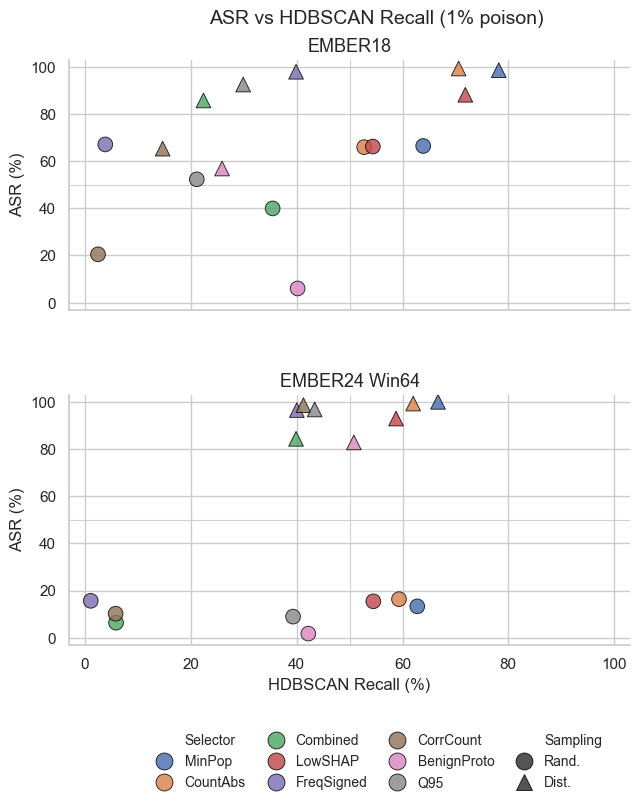

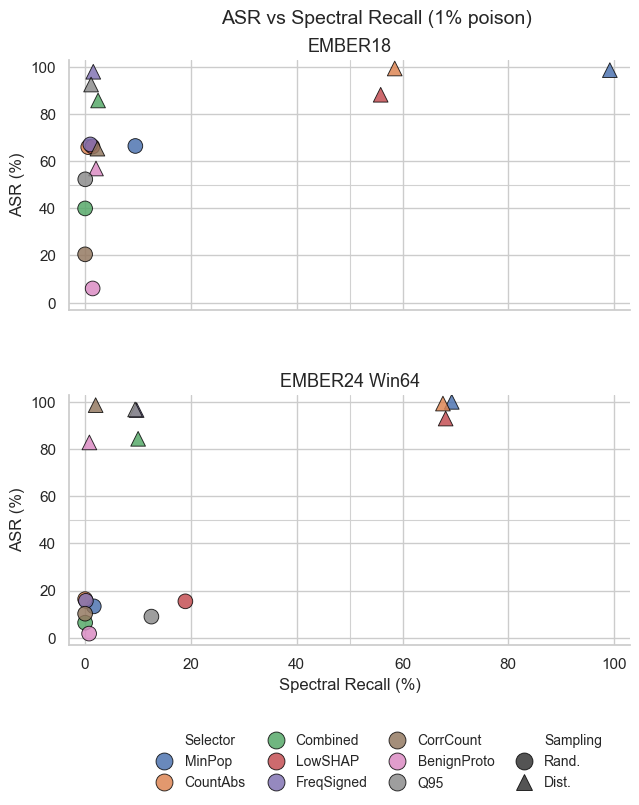

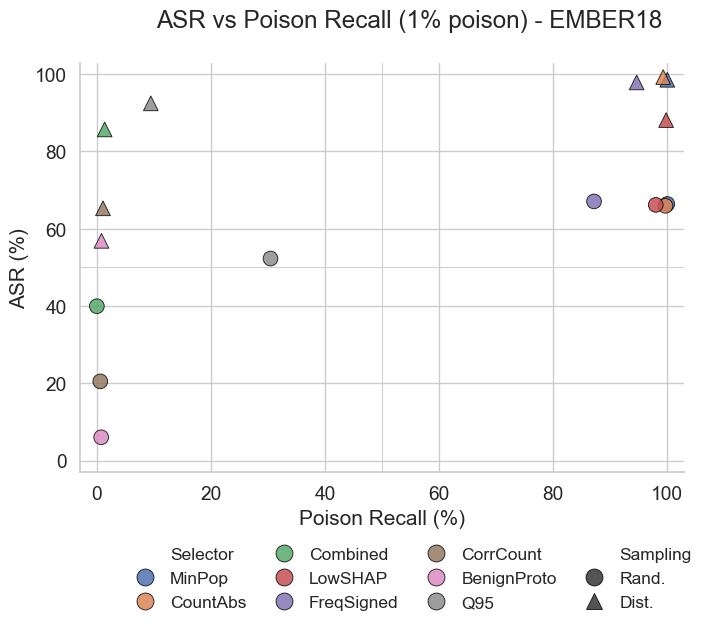

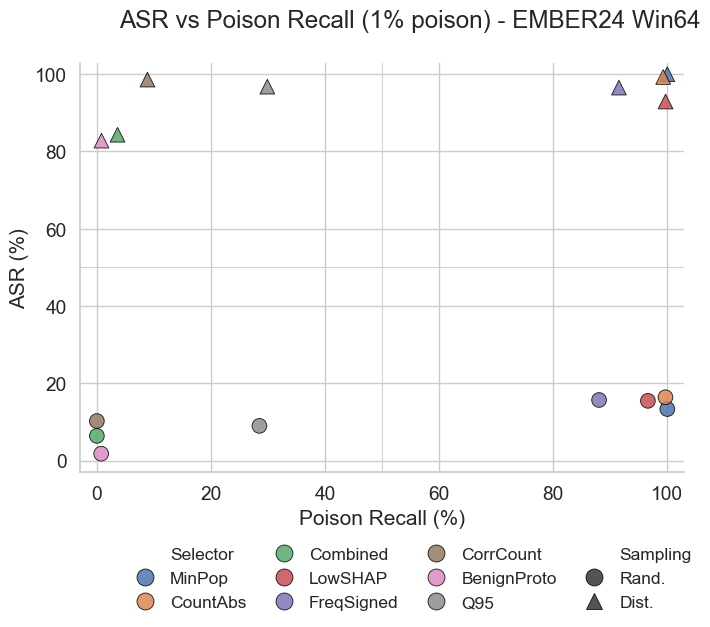

Saved ASR-vs-defense plots:


/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/plots/final_result/poison_1p/asr_vs_hdbscan_recall_1p.pdf

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/plots/final_result/poison_1p/asr_vs_hdbscan_recall_1p.png

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/plots/final_result/poison_1p/asr_vs_spectral_signature_recall_1p.pdf

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/plots/final_result/poison_1p/asr_vs_spectral_signature_recall_1p.png

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/plots/final_result/poison_1p/asr_vs_isolation_forest_recall_ember18_1p.pdf

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/plots/final_result/poison_1p/asr_vs_isolation_forest_recall_ember18_1p.png

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/plots/final_result/poison_1p/asr_vs_isolation_forest_recall_ember24_win64_1p.pdf

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/plots/final_result/poison_1p/asr_vs_isolation_forest_recall_ember24_win64_1p.png

In [7]:
plot_source_table = paper_table.copy()
plot_rows = []
for _, row in plot_source_table.dropna(subset=["attack_effectiveness_percent"]).iterrows():
    for method in DEFENSES_FOR_TABLE:
        recall_col = f"{method}_poison_recall_percent"
        if recall_col not in plot_source_table.columns or pd.isna(row.get(recall_col)):
            continue
        plot_rows.append(
            {
                "dataset_label": row.get("dataset_label"),
                "selector": row.get("selector"),
                "selector_order": row.get("selector_order"),
                "sampling_label": row.get("sampling_label"),
                "attack_effectiveness_percent": row.get("attack_effectiveness_percent"),
                "defense_method": method,
                "defense_label": DEFENSE_LABELS.get(method, method),
                "poison_recall_percent": row.get(recall_col),
            }
        )

tradeoff_plot_df = pd.DataFrame(plot_rows)

PLOT_SELECTOR_LABELS = {
    "MinPopulation": "MinPop",
    "CountAbsSHAP-style": "CountAbs",
    "CombinedSHAP-style": "Combined",
    "LowShapSigned": "LowSHAP",
    "FrequencyBounded SignedSHAP": "FreqSigned",
    "CorrCountAbsSHAP": "CorrCount",
    "BenignPrototype": "BenignProto",
    "QuantileDistribution Q95": "Q95",
}
PLOT_SAMPLING_LABELS = {
    "Distribution-based": "Dist.",
    "Random": "Rand.",
}
PLOT_SAMPLING_MARKERS = {
    "Rand.": "o",
    "Dist.": "^",
}
PLOT_DATASET_LABELS = {
    "EMBER2018": "EMBER18",
    "EMBER2024 WIN64": "EMBER24 Win64",
}
PLOT_DEFENSE_LABELS = {
    "hdbscan": "HDBSCAN",
    "spectral_signature": "Spectral",
    "isolation_forest": "IsolationForest",
}

if not tradeoff_plot_df.empty:
    tradeoff_plot_df["Selector"] = tradeoff_plot_df["selector"].map(PLOT_SELECTOR_LABELS).fillna(tradeoff_plot_df["selector"])
    tradeoff_plot_df["Sampling"] = tradeoff_plot_df["sampling_label"].map(PLOT_SAMPLING_LABELS).fillna(tradeoff_plot_df["sampling_label"])
    tradeoff_plot_df["Dataset"] = tradeoff_plot_df["dataset_label"].map(PLOT_DATASET_LABELS).fillna(tradeoff_plot_df["dataset_label"])


def add_display_nudge(df):
    """Separate visually overlapping markers without changing the table values."""
    out = df.copy()
    selector_order = out["selector_order"].fillna(0).astype(int)
    sampling_sign = out["sampling_label"].map({"Distribution-based": 1.0, "Random": -1.0}).fillna(0.0)
    angle = selector_order * 2.399963 + sampling_sign * 0.85
    radius = 0.9 + (selector_order % 3) * 0.18
    dx = np.cos(angle) * radius + sampling_sign * 0.35
    dy = np.sin(angle) * radius + sampling_sign * 0.35
    out["poison_recall_plot"] = np.clip(out["poison_recall_percent"] + dx, 0, 100)
    out["attack_effectiveness_plot"] = np.clip(out["attack_effectiveness_percent"] + dy, 0, 100)
    return out


def plot_file_slug(value):
    return (
        str(value)
        .lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("%", "p")
        .replace("-", "_")
        .replace(".", "")
    )

plot_out_dir = RESULTS_ROOT / "plots" / "final_result" / f"poison_{MAIN_POISON_RATE:.0%}".replace("%", "p")
plot_out_dir.mkdir(parents=True, exist_ok=True)
saved_tradeoff_plots = []

if tradeoff_plot_df.empty:
    print("No rows available for ASR-vs-defense-recall plot.")
else:
    selector_order = [
        PLOT_SELECTOR_LABELS.get(label, label)
        for label in paper_table.sort_values("selector_order")["selector"].drop_duplicates().tolist()
        if PLOT_SELECTOR_LABELS.get(label, label) in set(tradeoff_plot_df["Selector"])
    ]
    sampling_order = ["Rand.", "Dist."]
    dataset_order = [PLOT_DATASET_LABELS.get(value, value) for value in FOCUS_DATASETS]
    for method in DEFENSES_FOR_TABLE:
        defense_title = PLOT_DEFENSE_LABELS.get(method, DEFENSE_LABELS.get(method, method))
        text_scale = 1.25 if method == "isolation_forest" else 1.0
        defense_df = tradeoff_plot_df[tradeoff_plot_df["defense_method"] == method].copy()
        if defense_df.empty:
            print(f"No rows available for {defense_title}.")
            continue

        dataset_groups = (
            [(None, defense_df)]
            if method != "isolation_forest"
            else [(dataset, group.copy()) for dataset, group in defense_df.groupby("Dataset", sort=False)]
        )

        for dataset_label, dataset_df in dataset_groups:
            defense_plot_df = add_display_nudge(dataset_df)
            style_order = [label for label in sampling_order if label in set(defense_plot_df["Sampling"])]
            facet_kwargs = (
                {
                    "row": "Dataset",
                    "row_order": [label for label in dataset_order if label in set(defense_plot_df["Dataset"])],
                    "height": 3.85,
                    "aspect": 1.72,
                    "facet_kws": {"sharex": True, "sharey": True},
                }
                if dataset_label is None
                else {
                    "height": 6.3 if method == "isolation_forest" else 4.2,
                    "aspect": 1.12 if method == "isolation_forest" else 1.62,
                    "facet_kws": {"sharex": True, "sharey": True},
                }
            )

            g = sns.relplot(
                data=defense_plot_df,
                x="poison_recall_plot",
                y="attack_effectiveness_plot",
                hue="Selector",
                style="Sampling",
                hue_order=selector_order,
                style_order=style_order,
                markers={label: PLOT_SAMPLING_MARKERS.get(label, "^") for label in style_order},
                kind="scatter",
                s=112,
                alpha=0.84,
                edgecolor="black",
                linewidth=0.65,
                **facet_kwargs,
            )
            recall_title = "Poison Recall" if method == "isolation_forest" else f"{defense_title} Recall"
            g.set_axis_labels(f"{recall_title} (%)", "ASR (%)")
            g.set_titles("{row_name}" if dataset_label is None else "")
            for ax in g.axes.flat:
                ax.set_xlim(-3, 103)
                ax.set_ylim(-3, 103)
                ax.axhline(50, color="0.82", linewidth=0.8, zorder=0)
                ax.axvline(50, color="0.82", linewidth=0.8, zorder=0)
                ax.tick_params(labelsize=11 * text_scale)
                ax.xaxis.label.set_size(12 * text_scale)
                ax.yaxis.label.set_size(12 * text_scale)
                ax.title.set_size(13 * text_scale)
            title_suffix = f" - {dataset_label}" if dataset_label is not None else ""
            g.fig.suptitle(
                f"ASR vs {recall_title} (1% poison){title_suffix}",
                y=0.985,
                fontsize=14 * text_scale,
            )
            if g._legend is not None:
                sns.move_legend(
                    g,
                    "lower center",
                    bbox_to_anchor=(0.5, 0.02 if method == "isolation_forest" else -0.035),
                    ncol=4,
                    frameon=False,
                    fontsize=10 * text_scale,
                    title_fontsize=10 * text_scale,
                    markerscale=1.15,
                    handletextpad=0.45,
                    columnspacing=1.15,
                    borderaxespad=0.0,
                )
            if dataset_label is None:
                g.fig.subplots_adjust(top=0.92, bottom=0.16, hspace=0.34)
                file_stem = f"asr_vs_{method}_recall_{MAIN_POISON_RATE:.0%}".replace("%", "p")
            else:
                g.fig.subplots_adjust(
                    top=0.90,
                    bottom=0.25 if method == "isolation_forest" else 0.24,
                )
                file_stem = f"asr_vs_{method}_recall_{plot_file_slug(dataset_label)}_{MAIN_POISON_RATE:.0%}".replace("%", "p")
            pdf_path = (plot_out_dir / file_stem).with_suffix(".pdf")
            png_path = pdf_path.with_suffix(".png")
            g.fig.savefig(pdf_path, bbox_inches="tight")
            g.fig.savefig(png_path, dpi=300, bbox_inches="tight")
            saved_tradeoff_plots.extend([pdf_path, png_path])
            plt.show()

if saved_tradeoff_plots:
    print("Saved ASR-vs-defense plots:")
    for path in saved_tradeoff_plots:
        display(FileLink(str(path)))


## Figure: Compact ASR And Isolation Forest Recall Bars

This paper-facing view compares the two most important values directly: ASR / evasion and Isolation Forest poison recall. Each dataset gets one figure, with Random and Distribution-based sampling shown as separate panels.

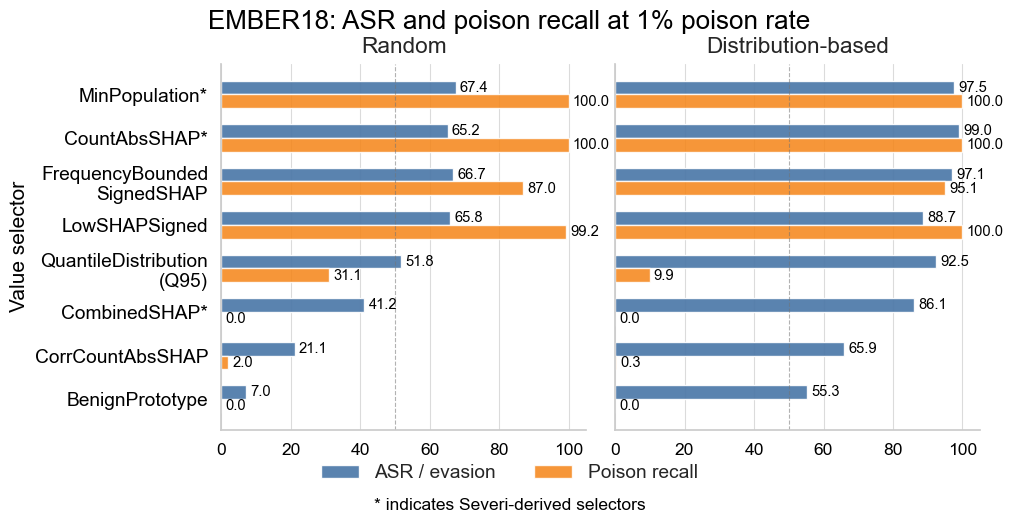

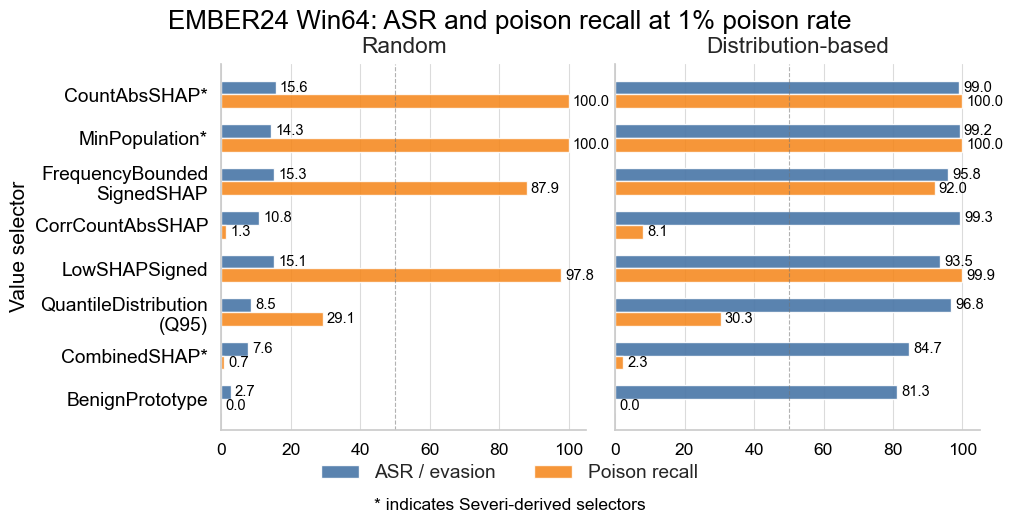

Saved compact ASR/poison recall bar plots:


/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/plots/final_result/poison_1p/compact_asr_if_recall_bars_ember18_1p.png

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/plots/final_result/poison_1p/compact_asr_if_recall_bars_ember18_1p.pdf

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/plots/final_result/poison_1p/compact_asr_if_recall_bars_ember24_win64_1p.png

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/plots/final_result/poison_1p/compact_asr_if_recall_bars_ember24_win64_1p.pdf

In [8]:
# Compact paired-bar figures for direct value comparison.
# One figure per dataset; within each figure, compare Random and Distribution-based sampling.
bar_metric_rows = []
for _, row in paper_table.dropna(subset=["attack_effectiveness_percent"]).iterrows():
    recall_value = row.get("isolation_forest_poison_recall_percent")
    if pd.isna(recall_value):
        continue
    bar_metric_rows.append(
        {
            "dataset_label": row.get("dataset_label"),
            "Dataset": PLOT_DATASET_LABELS.get(row.get("dataset_label"), row.get("dataset_label")),
            "sampling_label": row.get("sampling_label"),
            "Sampling": PLOT_SAMPLING_LABELS.get(row.get("sampling_label"), row.get("sampling_label")),
            "selector": row.get("selector"),
            "Selector": PLOT_SELECTOR_LABELS.get(row.get("selector"), row.get("selector")),
            "selector_order": row.get("selector_order"),
            "ASR": row.get("attack_effectiveness_percent"),
            "Poison recall": recall_value,
        }
    )

compact_bar_df = pd.DataFrame(bar_metric_rows)
compact_bar_paths = []
compact_poison_label_for_file = f"{MAIN_POISON_RATE:.0%}".replace("%", "p")

BAR_METRIC_COLORS = {
    "ASR": "#4C78A8",
    "Poison recall": "#F58518",
}
BAR_TEXT_SCALE = 1.25


def _format_percent_label(value):
    if pd.isna(value):
        return ""
    return f"{float(value):.1f}"


def _add_bar_value_label(ax, value, y):
    if pd.isna(value):
        return
    value = float(value)
    ax.text(
        min(value + 1.2, 103.0),
        y,
        _format_percent_label(value),
        va="center",
        ha="left",
        fontsize=8.5 * BAR_TEXT_SCALE,
        color="black",
    )


BAR_SELECTOR_LABELS = {
    "MinPopulation": "MinPopulation*",
    "CountAbsSHAP-style": "CountAbsSHAP*",
    "CombinedSHAP-style": "CombinedSHAP*",
    "LowShapSigned": "LowSHAPSigned",
    "FrequencyBounded SignedSHAP": "FrequencyBounded\nSignedSHAP",
    "CorrCountAbsSHAP": "CorrCountAbsSHAP",
    "BenignPrototype": "BenignPrototype",
    "QuantileDistribution Q95": "QuantileDistribution\n(Q95)",
}


def plot_compact_asr_if_bars(dataset_label, dataset_df):
    selector_ranking = (
        dataset_df.groupby("selector", as_index=False)
        .agg(mean_asr=("ASR", "mean"), selector_order=("selector_order", "min"))
        .sort_values(["mean_asr", "selector_order"], ascending=[False, True])
    )
    selector_order_raw = selector_ranking["selector"].tolist()
    selector_order = [PLOT_SELECTOR_LABELS.get(label, label) for label in selector_order_raw]
    selector_tick_labels = [BAR_SELECTOR_LABELS.get(label, label) for label in selector_order_raw]
    sampling_order = ["Rand.", "Dist."]

    fig, axes = plt.subplots(1, 2, figsize=(9.6, 5.15), sharex=True, sharey=True)
    axes = np.atleast_1d(axes)
    y_positions = np.arange(len(selector_order))
    bar_height = 0.32

    for ax, sampling_label in zip(axes, sampling_order):
        sub = dataset_df[dataset_df["Sampling"] == sampling_label].set_index("Selector")
        asr_values = [sub.loc[name, "ASR"] if name in sub.index else np.nan for name in selector_order]
        recall_values = [sub.loc[name, "Poison recall"] if name in sub.index else np.nan for name in selector_order]

        ax.barh(
            y_positions - bar_height / 2,
            asr_values,
            height=bar_height,
            color=BAR_METRIC_COLORS["ASR"],
            alpha=0.92,
            label="ASR / evasion",
        )
        ax.barh(
            y_positions + bar_height / 2,
            recall_values,
            height=bar_height,
            color=BAR_METRIC_COLORS["Poison recall"],
            alpha=0.86,
            label="Poison recall",
        )

        for y, value in zip(y_positions - bar_height / 2, asr_values):
            _add_bar_value_label(ax, value, y)
        for y, value in zip(y_positions + bar_height / 2, recall_values):
            _add_bar_value_label(ax, value, y)

        ax.set_title("Random" if sampling_label == "Rand." else "Distribution-based", fontsize=13 * BAR_TEXT_SCALE, pad=8)
        ax.set_xlim(0, 105)
        ax.set_xlabel("")
        ax.axvline(50, color="0.45", lw=0.8, ls="--", alpha=0.55)
        ax.grid(axis="x", color="0.86", lw=0.8)
        ax.grid(axis="y", visible=False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="x", labelsize=10 * BAR_TEXT_SCALE, colors="black")
        ax.tick_params(axis="y", labelsize=11 * BAR_TEXT_SCALE, colors="black")

    axes[0].set_yticks(y_positions)
    axes[0].set_yticklabels(selector_tick_labels, fontsize=11 * BAR_TEXT_SCALE, color="black")
    axes[0].invert_yaxis()
    axes[0].set_ylabel("Value selector", fontsize=12 * BAR_TEXT_SCALE, color="black")
    axes[1].tick_params(axis="y", left=False, labelleft=False)

    dataset_title = PLOT_DATASET_LABELS.get(dataset_label, dataset_label)
    fig.suptitle(f"{dataset_title}: ASR and poison recall at {MAIN_POISON_RATE:.0%} poison rate", fontsize=15 * BAR_TEXT_SCALE, y=0.985, color="black")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.035), ncol=2, frameon=False, fontsize=11 * BAR_TEXT_SCALE)
    fig.text(0.5, 0.008, "* indicates Severi-derived selectors", ha="center", va="bottom", fontsize=10 * BAR_TEXT_SCALE, color="black")
    fig.subplots_adjust(left=0.20, right=0.99, top=0.88, bottom=0.17, wspace=0.08)
    return fig


if compact_bar_df.empty:
    print("No Isolation Forest rows available for compact ASR/recall bar plots.")
else:
    for dataset_label in FOCUS_DATASETS:
        dataset_df = compact_bar_df[compact_bar_df["dataset_label"] == dataset_label].copy()
        if dataset_df.empty:
            print(f"No rows available for {dataset_label}.")
            continue
        fig = plot_compact_asr_if_bars(dataset_label, dataset_df)
        dataset_slug = plot_file_slug(PLOT_DATASET_LABELS.get(dataset_label, dataset_label))
        png_path = plot_out_dir / f"compact_asr_if_recall_bars_{dataset_slug}_{compact_poison_label_for_file}.png"
        pdf_path = plot_out_dir / f"compact_asr_if_recall_bars_{dataset_slug}_{compact_poison_label_for_file}.pdf"
        fig.savefig(png_path, dpi=300, bbox_inches="tight")
        fig.savefig(pdf_path, bbox_inches="tight")
        compact_bar_paths.extend([png_path, pdf_path])
        display(fig)
        plt.close(fig)

    print("Saved compact ASR/poison recall bar plots:")
    for path in compact_bar_paths:
        display(FileLink(str(path)))


## Heatmap: ASR / Evasion at Selected Poison Rate

This view uses only the selected poison rate.

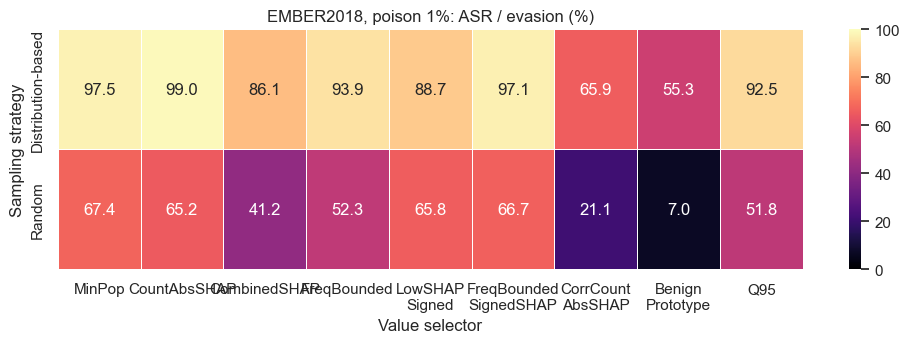

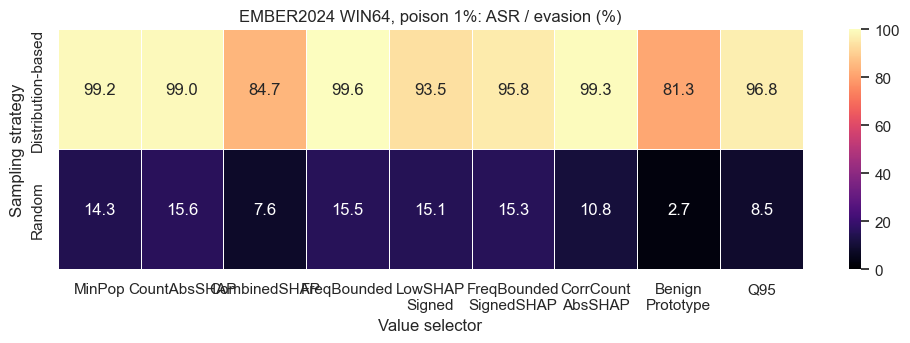

In [9]:
def ordered_selector_pivot(df, *, index, columns, values):
    pivot = df.pivot_table(index=index, columns=columns, values=values, aggfunc="mean", observed=True)
    if columns == "selector":
        ordered_labels = selector_taxonomy["selector"].tolist()
        pivot = pivot.reindex(columns=[label for label in ordered_labels if label in pivot.columns])
    return pivot.dropna(how="all", axis=0).dropna(how="all", axis=1)

HEATMAP_SELECTOR_LABELS = {
    "MinPopulation": "MinPop",
    "CountAbsSHAP-style": "CountAbsSHAP",
    "CombinedSHAP-style": "CombinedSHAP",
    "FrequencyBounded": "FreqBounded",
    "LowShapSigned": "LowSHAP\nSigned",
    "SignedShapMinSum": "SignedSHAP\nMinSum",
    "FrequencyBounded SignedSHAP": "FreqBounded\nSignedSHAP",
    "CorrCountAbsSHAP": "CorrCount\nAbsSHAP",
    "BenignPrototype": "Benign\nPrototype",
    "QuantileDistribution Q95": "Q95",
}

heatmap_df = attack_df[np.isclose(attack_df["poison_rate_train"], MAIN_POISON_RATE, atol=1e-12)].copy()
for (dataset, poison_label), group in heatmap_df.groupby(["dataset_label", "poison_rate_label"], dropna=False):
    pivot = ordered_selector_pivot(
        group,
        index="sampling_label",
        columns="selector",
        values="attack_effectiveness_percent",
    )
    if pivot.empty:
        continue
    width = max(10, 0.85 * pivot.shape[1] + 2.5)
    fig, ax = plt.subplots(figsize=(width, 3.6))
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="magma", vmin=0, vmax=100, linewidths=0.5, linecolor="white", ax=ax)
    ax.set_title(f"{dataset}, poison {poison_label}: ASR / evasion (%)")
    ax.set_xlabel("Value selector")
    ax.set_ylabel("Sampling strategy")
    ax.set_xticklabels([HEATMAP_SELECTOR_LABELS.get(label.get_text(), label.get_text()) for label in ax.get_xticklabels()], rotation=0)
    plt.tight_layout()
    plt.show()


## Download Tables

The notebook writes the paper-facing tables as per-dataset CSV files and one Excel workbook with separate sheets for EMBER2018 and EMBER2024 WIN64.

In [10]:
def safe_filename(value):
    return (
        str(value)
        .lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("%", "p")
        .replace("-", "_")
    )

poison_label_for_file = f"{MAIN_POISON_RATE:.0%}".replace("%", "p")
out_dir = RESULTS_ROOT / "tables" / "final_result" / f"poison_{poison_label_for_file}"
out_dir.mkdir(parents=True, exist_ok=True)

export_paths = []
selector_taxonomy_path = out_dir / "selector_taxonomy.csv"
selector_taxonomy.to_csv(selector_taxonomy_path, index=False)
export_paths.append(selector_taxonomy_path)

wide_all_path = out_dir / f"paper_table_wide_{poison_label_for_file}.csv"
defense_all_path = out_dir / f"paper_table_defense_long_{poison_label_for_file}.csv"
paper_table.to_csv(wide_all_path, index=False)
defense_long_table.to_csv(defense_all_path, index=False)
export_paths.extend([wide_all_path, defense_all_path])

for dataset, group in paper_table.groupby("dataset_label", sort=False):
    path = out_dir / f"paper_table_wide_{poison_label_for_file}_{safe_filename(dataset)}.csv"
    group.to_csv(path, index=False)
    export_paths.append(path)

for dataset, group in defense_long_table.groupby("Dataset", sort=False):
    path = out_dir / f"paper_table_defense_long_{poison_label_for_file}_{safe_filename(dataset)}.csv"
    group.to_csv(path, index=False)
    export_paths.append(path)

excel_path = out_dir / f"paper_tables_{poison_label_for_file}.xlsx"
try:
    with pd.ExcelWriter(excel_path) as writer:
        selector_taxonomy.to_excel(writer, sheet_name="selector_taxonomy", index=False)
        paper_table.to_excel(writer, sheet_name="wide_all", index=False)
        defense_long_table.to_excel(writer, sheet_name="defense_all", index=False)
        for dataset, group in paper_table.groupby("dataset_label", sort=False):
            sheet = f"wide_{safe_filename(dataset)}"[:31]
            group.to_excel(writer, sheet_name=sheet, index=False)
        for dataset, group in defense_long_table.groupby("Dataset", sort=False):
            sheet = f"def_{safe_filename(dataset)}"[:31]
            group.to_excel(writer, sheet_name=sheet, index=False)
    export_paths.append(excel_path)
except Exception as exc:
    print(f"Excel export skipped: {exc}")

print("Saved downloadable tables to", out_dir)
for path in export_paths:
    display(FileLink(str(path)))


Saved downloadable tables to /Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/tables/final_result/poison_1p


/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/tables/final_result/poison_1p/selector_taxonomy.csv

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/tables/final_result/poison_1p/paper_table_wide_1p.csv

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/tables/final_result/poison_1p/paper_table_defense_long_1p.csv

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/tables/final_result/poison_1p/paper_table_wide_1p_ember2018.csv

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/tables/final_result/poison_1p/paper_table_wide_1p_ember2024_win64.csv

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/tables/final_result/poison_1p/paper_table_defense_long_1p_ember2018.csv

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/tables/final_result/poison_1p/paper_table_defense_long_1p_ember2024_win64.csv

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/tables/final_result/poison_1p/paper_tables_1p.xlsx

## Seed Comparison: Seed 42 Versus Seed 43

This section is intentionally separate from the original final-result cells. It classifies the existing result roots explicitly so that the old seed-42 results and the newer seed-43 results are compared as matched experiments. It then computes two-seed means and standard deviations for the 1% poison-rate setting.


In [11]:
SEED_COMPARISON_OUTPUT = RESULTS_ROOT / 'plots' / 'final_result' / 'poison_1p_seed_comparison'
SEED_COMPARISON_OUTPUT.mkdir(parents=True, exist_ok=True)
SEED42_ROOTS = {'EMBER2018': 'ember/20p_balanced', 'EMBER2024 WIN64': 'ember2024/win64'}
SEED43_ROOTS = {'EMBER2018': 'ember2018', 'EMBER2024 WIN64': 'ember2024_win64'}
COMMON_SELECTORS = [
    'min_population_new', 'argmin_Nv_sum_abs_shap', 'combined_shap',
    'low_shap_signed', 'frequency_bounded_signed_shap',
    'corr_count_abs_shap', 'benign_prototype', 'quantile_95',
]
SEED_LABELS = {42: 'Seed 42', 43: 'Seed 43'}
SEED_SELECTOR_LABELS = {
    'min_population_new': 'MinPopulation*',
    'argmin_Nv_sum_abs_shap': 'CountAbsSHAP*',
    'combined_shap': 'CombinedSHAP*',
    'low_shap_signed': 'LowSHAPSigned',
    'frequency_bounded_signed_shap': 'FrequencyBoundedSignedSHAP',
    'corr_count_abs_shap': 'CorrCountAbsSHAP',
    'benign_prototype': 'BenignPrototype',
    'quantile_95': 'Quantile95',
}
SEED_DATASET_LABELS = {'EMBER2018': 'EMBER2018', 'EMBER2024 WIN64': 'EMBER2024 Win64'}
SEED_SAMPLING_LABELS = {'random': 'Random', 'distribution_based_distance': 'Distribution-based'}
SEED_DEFENSE_LABELS = {'hdbscan': 'HDBSCAN', 'spectral_signature': 'Spectral Signature', 'isolation_forest': 'Isolation Forest'}
SEED_COLORS = dict(zip(COMMON_SELECTORS, sns.color_palette('tab10', n_colors=len(COMMON_SELECTORS))))
SEED_MARKERS = {'Random': 'o', 'Distribution-based': '^'}
SEED_DEFENSES = ['hdbscan', 'spectral_signature', 'isolation_forest']

def classify_experiment_seed(frame, roots42, roots43):
    out = frame.copy()
    normalized_path = out['dataset_path'].astype(str).str.replace('\\', '/', regex=False)
    out['experiment_seed'] = pd.Series(pd.NA, index=out.index, dtype='Int64')
    for dataset, root in roots42.items():
        mask = normalized_path.eq(root)
        out.loc[mask, 'experiment_seed'] = 42
        out.loc[mask, 'dataset_label'] = dataset
    for dataset, root in roots43.items():
        mask = normalized_path.eq(root)
        out.loc[mask, 'experiment_seed'] = 43
        out.loc[mask, 'dataset_label'] = dataset
    return out[out['experiment_seed'].notna()].copy()

def prepare_seed_attack_data():
    frame = classify_experiment_seed(load_attack_summaries(RESULTS_ROOT), SEED42_ROOTS, SEED43_ROOTS)
    frame = frame[
        frame['experiment_seed'].isin([42, 43])
        & np.isclose(frame['poison_rate_train'], MAIN_POISON_RATE, atol=1e-12)
        & frame['sampling_strategy'].isin(FOCUS_SAMPLINGS)
        & frame['target_features'].eq('problem_space_conservative')
        & frame['value_selector'].isin(COMMON_SELECTORS)
    ].copy()
    frame['selector'] = frame['value_selector'].map(SEED_SELECTOR_LABELS)
    frame['dataset'] = frame['dataset_label'].map(SEED_DATASET_LABELS)
    frame['sampling'] = frame['sampling_strategy'].map(SEED_SAMPLING_LABELS)
    keys = ['experiment_seed', 'dataset', 'sampling_strategy', 'value_selector']
    return latest_unique(frame, keys)

def prepare_seed_detector_data():
    frame = classify_experiment_seed(load_detector_metrics(RESULTS_ROOT), SEED42_ROOTS, SEED43_ROOTS)
    frame = frame[
        frame['experiment_seed'].isin([42, 43])
        & np.isclose(frame['poison_rate_train'], MAIN_POISON_RATE, atol=1e-12)
        & frame['sampling_strategy'].isin(FOCUS_SAMPLINGS)
        & frame['target_features'].eq('problem_space_conservative')
        & frame['value_selector'].isin(COMMON_SELECTORS)
        & frame['defense_method'].isin(SEED_DEFENSES)
    ].copy()
    frame['selector'] = frame['value_selector'].map(SEED_SELECTOR_LABELS)
    frame['dataset'] = frame['dataset_label'].map(SEED_DATASET_LABELS)
    frame['sampling'] = frame['sampling_strategy'].map(SEED_SAMPLING_LABELS)
    keys = ['experiment_seed', 'dataset', 'sampling_strategy', 'value_selector', 'defense_method']
    return latest_unique(frame, keys)

seed_attack = prepare_seed_attack_data()
seed_detector = prepare_seed_detector_data()
print('Seed-level attack rows:', len(seed_attack))
print('Seed-level detector rows:', len(seed_detector))
display(seed_attack.groupby(['experiment_seed', 'dataset', 'sampling'], dropna=False).agg(rows=('value_selector', 'nunique')).reset_index())
display(seed_detector.groupby(['experiment_seed', 'dataset', 'sampling', 'defense_method'], dropna=False).size().reset_index(name='rows'))


Seed-level attack rows: 64
Seed-level detector rows: 192


,experiment_seed,dataset,sampling,rows
0,42,EMBER2018,Distribution-based,8
1,42,EMBER2018,Random,8
2,42,EMBER2024 Win64,Distribution-based,8
3,42,EMBER2024 Win64,Random,8
4,43,EMBER2018,Distribution-based,8
5,43,EMBER2018,Random,8
6,43,EMBER2024 Win64,Distribution-based,8
7,43,EMBER2024 Win64,Random,8


,experiment_seed,dataset,sampling,defense_method,rows
0,42,EMBER2018,Distribution-based,hdbscan,8
1,42,EMBER2018,Distribution-based,isolation_forest,8
2,42,EMBER2018,Distribution-based,spectral_signature,8
3,42,EMBER2018,Random,hdbscan,8
4,42,EMBER2018,Random,isolation_forest,8
5,42,EMBER2018,Random,spectral_signature,8
6,42,EMBER2024 Win64,Distribution-based,hdbscan,8
7,42,EMBER2024 Win64,Distribution-based,isolation_forest,8
8,42,EMBER2024 Win64,Distribution-based,spectral_signature,8
9,42,EMBER2024 Win64,Random,hdbscan,8


### Seed-Level Effectiveness And Detectability

The following table keeps the two seeds separate. `ASR / evasion` is the attack-effectiveness metric; poison recall is shown for each sanitizer.


In [12]:
seed_attack_small = seed_attack[['experiment_seed', 'dataset', 'sampling', 'selector', 'value_selector', 'attack_effectiveness_percent', 'backdoored_clean_accuracy_percent']].copy()
seed_detector_small = seed_detector[['experiment_seed', 'dataset', 'sampling', 'selector', 'value_selector', 'defense_method', 'poison_recall_percent', 'clean_false_positive_rate_percent', 'removed_poisoned_rows', 'removed_clean_rows']].copy()
seed_detector_pivot = seed_detector_small.pivot_table(index=['experiment_seed', 'dataset', 'sampling', 'selector', 'value_selector'], columns='defense_method', values=['poison_recall_percent', 'clean_false_positive_rate_percent', 'removed_poisoned_rows', 'removed_clean_rows'], aggfunc='first').reset_index()
seed_detector_pivot.columns = [('_'.join(str(part) for part in col if str(part) not in {'', 'None'}) if isinstance(col, tuple) else col) for col in seed_detector_pivot.columns]
seed_wide = seed_attack_small.merge(seed_detector_pivot, on=['experiment_seed', 'dataset', 'sampling', 'selector', 'value_selector'], how='left')
seed_wide = seed_wide.sort_values(['dataset', 'sampling', 'selector', 'experiment_seed']).reset_index(drop=True)
display(seed_wide.round(3))
seed_wide.to_csv(SEED_COMPARISON_OUTPUT / 'seed_level_effectiveness_detectability.csv', index=False)


,experiment_seed,dataset,sampling,selector,value_selector,attack_effectiveness_percent,backdoored_clean_accuracy_percent,clean_false_positive_rate_percent_hdbscan,clean_false_positive_rate_percent_isolation_forest,clean_false_positive_rate_percent_spectral_signature,poison_recall_percent_hdbscan,poison_recall_percent_isolation_forest,poison_recall_percent_spectral_signature,removed_clean_rows_hdbscan,removed_clean_rows_isolation_forest,removed_clean_rows_spectral_signature,removed_poisoned_rows_hdbscan,removed_poisoned_rows_isolation_forest,removed_poisoned_rows_spectral_signature
0,42,EMBER2018,Distribution-based,BenignPrototype,benign_prototype,29.990,97.859,36.825,2.037,2.037,36.000,0.000,0.167,21653,1198,1198,432,0,2
1,43,EMBER2018,Distribution-based,BenignPrototype,benign_prototype,55.340,97.490,33.272,2.041,2.015,25.083,0.000,1.250,19564,1200,1185,301,0,15
2,42,EMBER2018,Distribution-based,CombinedSHAP*,combined_shap,87.613,98.000,37.895,2.041,2.037,32.500,0.000,0.167,22282,1200,1198,390,0,2
3,43,EMBER2018,Distribution-based,CombinedSHAP*,combined_shap,86.099,97.807,33.886,2.041,2.019,21.000,0.000,1.083,19925,1200,1187,252,0,13
4,42,EMBER2018,Distribution-based,CorrCountAbsSHAP,corr_count_abs_shap,92.720,97.817,40.509,2.002,2.041,39.083,1.917,0.000,23819,1177,1200,469,23,0
5,43,EMBER2018,Distribution-based,CorrCountAbsSHAP,corr_count_abs_shap,65.940,97.587,33.867,2.034,2.009,13.917,0.333,1.583,19914,1196,1181,167,4,19
6,42,EMBER2018,Distribution-based,CountAbsSHAP*,argmin_Nv_sum_abs_shap,98.729,97.863,33.713,0.012,0.854,76.250,99.417,58.167,19823,7,502,915,1193,698
7,43,EMBER2018,Distribution-based,CountAbsSHAP*,argmin_Nv_sum_abs_shap,99.021,97.979,34.017,0.000,0.832,71.333,100.000,59.250,20002,0,489,856,1200,711
8,42,EMBER2018,Distribution-based,FrequencyBoundedSignedSHAP,frequency_bounded_signed_shap,93.571,97.973,42.077,0.294,2.017,32.000,85.583,1.167,24741,173,1186,384,1027,14
9,43,EMBER2018,Distribution-based,FrequencyBoundedSignedSHAP,frequency_bounded_signed_shap,97.125,98.001,33.277,0.100,2.000,40.333,95.083,2.000,19567,59,1176,484,1141,24


## Two-Seed Mean And Standard Deviation

These summaries use matched seed-42 and seed-43 rows only. The error bars show the sample standard deviation across the two seeds (`ddof=1`); with two seeds, this describes run-to-run variation rather than a stable population estimate.


In [13]:
matched_attack = (seed_attack.groupby(['dataset', 'sampling_strategy', 'sampling', 'selector', 'value_selector'], dropna=False)
    .agg(seed_count=('experiment_seed', 'nunique'), asr_mean=('attack_effectiveness_percent', 'mean'), asr_std=('attack_effectiveness_percent', 'std'), clean_accuracy_mean=('backdoored_clean_accuracy_percent', 'mean'), clean_accuracy_std=('backdoored_clean_accuracy_percent', 'std'))
    .reset_index())
matched_detector_long = (seed_detector.groupby(['dataset', 'sampling_strategy', 'sampling', 'selector', 'value_selector', 'defense_method'], dropna=False)
    .agg(seed_count=('experiment_seed', 'nunique'), poison_recall_mean=('poison_recall_percent', 'mean'), poison_recall_std=('poison_recall_percent', 'std'), clean_fpr_mean=('clean_false_positive_rate_percent', 'mean'), clean_fpr_std=('clean_false_positive_rate_percent', 'std'))
    .reset_index())
matched_attack = matched_attack[matched_attack['seed_count'].eq(2)].copy()
matched_detector_long = matched_detector_long[matched_detector_long['seed_count'].eq(2)].copy()
matched_detector = matched_detector_long.pivot_table(
    index=['dataset', 'sampling_strategy', 'sampling', 'selector', 'value_selector'],
    columns='defense_method',
    values=['poison_recall_mean', 'poison_recall_std', 'clean_fpr_mean', 'clean_fpr_std'],
    aggfunc='first',
).reset_index()
flat_columns = []
for col in matched_detector.columns:
    if isinstance(col, tuple) and len(col) == 2:
        metric, method = col
        flat_columns.append(f'{metric}_{method}' if method not in {'', 'None'} else str(metric))
    else:
        flat_columns.append(col)
matched_detector.columns = flat_columns
mean_std = matched_attack.merge(matched_detector, on=['dataset', 'sampling_strategy', 'sampling', 'selector', 'value_selector'], how='left')
display(mean_std.round(3))
mean_std.to_csv(SEED_COMPARISON_OUTPUT / 'two_seed_mean_std_effectiveness_detectability.csv', index=False)
print('Matched mean/std rows:', len(mean_std))


,dataset,sampling_strategy,sampling,selector,value_selector,seed_count,asr_mean,asr_std,clean_accuracy_mean,clean_accuracy_std,clean_fpr_mean_hdbscan,clean_fpr_mean_isolation_forest,clean_fpr_mean_spectral_signature,clean_fpr_std_hdbscan,clean_fpr_std_isolation_forest,clean_fpr_std_spectral_signature,poison_recall_mean_hdbscan,poison_recall_mean_isolation_forest,poison_recall_mean_spectral_signature,poison_recall_std_hdbscan,poison_recall_std_isolation_forest,poison_recall_std_spectral_signature
0,EMBER2018,distribution_based_distance,Distribution-based,BenignPrototype,benign_prototype,2,42.665,17.925,97.675,0.262,35.048,2.039,2.026,2.512,0.002,0.016,30.542,0.000,0.708,7.719,0.000,0.766
1,EMBER2018,distribution_based_distance,Distribution-based,CombinedSHAP*,combined_shap,2,86.856,1.070,97.904,0.137,35.890,2.041,2.028,2.834,0.000,0.013,26.750,0.000,0.625,8.132,0.000,0.648
2,EMBER2018,distribution_based_distance,Distribution-based,CorrCountAbsSHAP,corr_count_abs_shap,2,79.330,18.937,97.702,0.163,37.188,2.018,2.025,4.696,0.023,0.023,26.500,1.125,0.792,17.796,1.120,1.120
3,EMBER2018,distribution_based_distance,Distribution-based,CountAbsSHAP*,argmin_Nv_sum_abs_shap,2,98.875,0.206,97.921,0.082,33.865,0.006,0.843,0.215,0.008,0.016,73.792,99.708,58.708,3.477,0.412,0.766
4,EMBER2018,distribution_based_distance,Distribution-based,FrequencyBoundedSignedSHAP,frequency_bounded_signed_shap,2,95.348,2.513,97.987,0.020,37.677,0.197,2.009,6.222,0.137,0.012,36.167,90.333,1.583,5.893,6.718,0.589
5,EMBER2018,distribution_based_distance,Distribution-based,LowSHAPSigned,low_shap_signed,2,88.743,0.062,97.817,0.193,37.636,0.027,1.456,6.277,0.038,0.791,60.083,98.625,28.667,16.971,1.945,38.773
6,EMBER2018,distribution_based_distance,Distribution-based,MinPopulation*,min_population_new,2,97.940,0.580,97.791,0.091,41.505,0.000,0.048,1.229,0.000,0.017,76.750,100.000,97.667,0.707,0.000,0.825
7,EMBER2018,distribution_based_distance,Distribution-based,Quantile95,quantile_95,2,93.745,1.758,97.776,0.110,39.832,1.912,2.025,6.875,0.103,0.023,32.000,6.333,0.792,2.357,5.068,1.120
8,EMBER2018,random,Random,BenignPrototype,benign_prototype,2,5.813,1.640,97.662,0.044,36.347,2.040,2.034,2.509,0.001,0.010,34.708,0.042,0.333,6.659,0.059,0.471
9,EMBER2018,random,Random,CombinedSHAP*,combined_shap,2,46.874,8.023,97.667,0.081,36.037,2.039,2.009,2.174,0.002,0.022,30.333,0.083,1.583,8.957,0.118,1.061


Matched mean/std rows: 32


## Figure: Two-Seed Mean ASR Versus Poison Recall

Each point is the mean of seeds 42 and 43. Horizontal and vertical error bars are the corresponding sample standard deviations. Panels are separated by dataset and sanitizer.


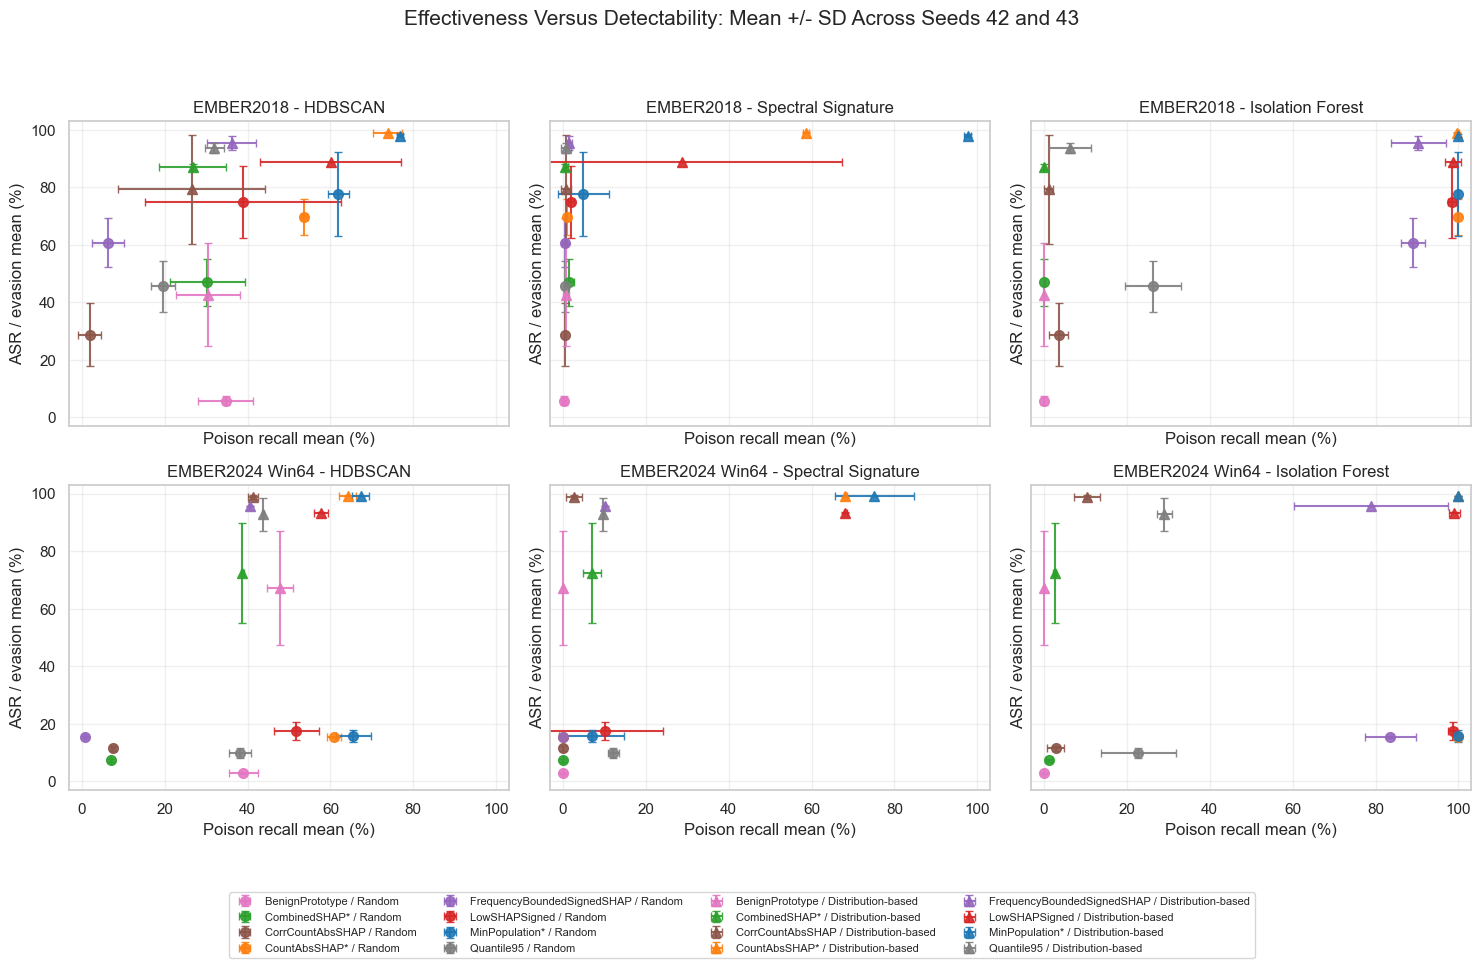

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/plots/final_result/poison_1p_seed_comparison/two_seed_mean_std_asr_vs_poison_recall.png

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/plots/final_result/poison_1p_seed_comparison/two_seed_mean_std_asr_vs_poison_recall.pdf

In [14]:
plot_rows = []
for _, row in mean_std.iterrows():
    for method in SEED_DEFENSES:
        recall_mean = row.get(f'poison_recall_mean_{method}')
        recall_std = row.get(f'poison_recall_std_{method}')
        if pd.isna(recall_mean):
            continue
        plot_rows.append({
            'dataset': row['dataset'], 'sampling': row['sampling'], 'sampling_strategy': row['sampling_strategy'],
            'selector': row['selector'], 'value_selector': row['value_selector'], 'defense_method': method,
            'asr_mean': row['asr_mean'], 'asr_std': row['asr_std'],
            'recall_mean': recall_mean, 'recall_std': recall_std,
        })
mean_tradeoff = pd.DataFrame(plot_rows)
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)
for ax, (dataset, method) in zip(axes.flat, [(d, m) for d in ['EMBER2018', 'EMBER2024 Win64'] for m in SEED_DEFENSES]):
    sub = mean_tradeoff[(mean_tradeoff['dataset'] == dataset) & (mean_tradeoff['defense_method'] == method)]
    for sampling in ['Random', 'Distribution-based']:
        s = sub[sub['sampling'] == sampling]
        for _, row in s.iterrows():
            ax.errorbar(row['recall_mean'], row['asr_mean'], xerr=row['recall_std'], yerr=row['asr_std'], fmt=SEED_MARKERS[sampling], color=SEED_COLORS[row['value_selector']], markersize=7, capsize=3, alpha=0.9, label=f"{row['selector']} / {sampling}")
    ax.set_title(f'{dataset} - {SEED_DEFENSE_LABELS[method]}')
    ax.set_xlim(-3, 103); ax.set_ylim(-3, 103)
    ax.set_xlabel('Poison recall mean (%)')
    ax.set_ylabel('ASR / evasion mean (%)')
    ax.grid(True, alpha=0.3)
handles, labels = axes.flat[0].get_legend_handles_labels()
if handles:
    unique = dict(zip(labels, handles))
    fig.legend(unique.values(), unique.keys(), loc='lower center', bbox_to_anchor=(0.5, -0.04), ncol=4, fontsize=8, frameon=True)
fig.suptitle('Effectiveness Versus Detectability: Mean +/- SD Across Seeds 42 and 43', y=1.02, fontsize=15)
fig.tight_layout(rect=[0, 0.08, 1, 0.98])
mean_tradeoff_png = SEED_COMPARISON_OUTPUT / 'two_seed_mean_std_asr_vs_poison_recall.png'
mean_tradeoff_pdf = SEED_COMPARISON_OUTPUT / 'two_seed_mean_std_asr_vs_poison_recall.pdf'
fig.savefig(mean_tradeoff_png, dpi=220, bbox_inches='tight'); fig.savefig(mean_tradeoff_pdf, bbox_inches='tight'); plt.show()
display(FileLink(str(mean_tradeoff_png))); display(FileLink(str(mean_tradeoff_pdf)))


## Figure: Mean ASR And Poison Recall With Standard Deviation

This paired-bar view is a compact alternative for the paper: each bar is the two-seed mean and each error bar is the standard deviation.


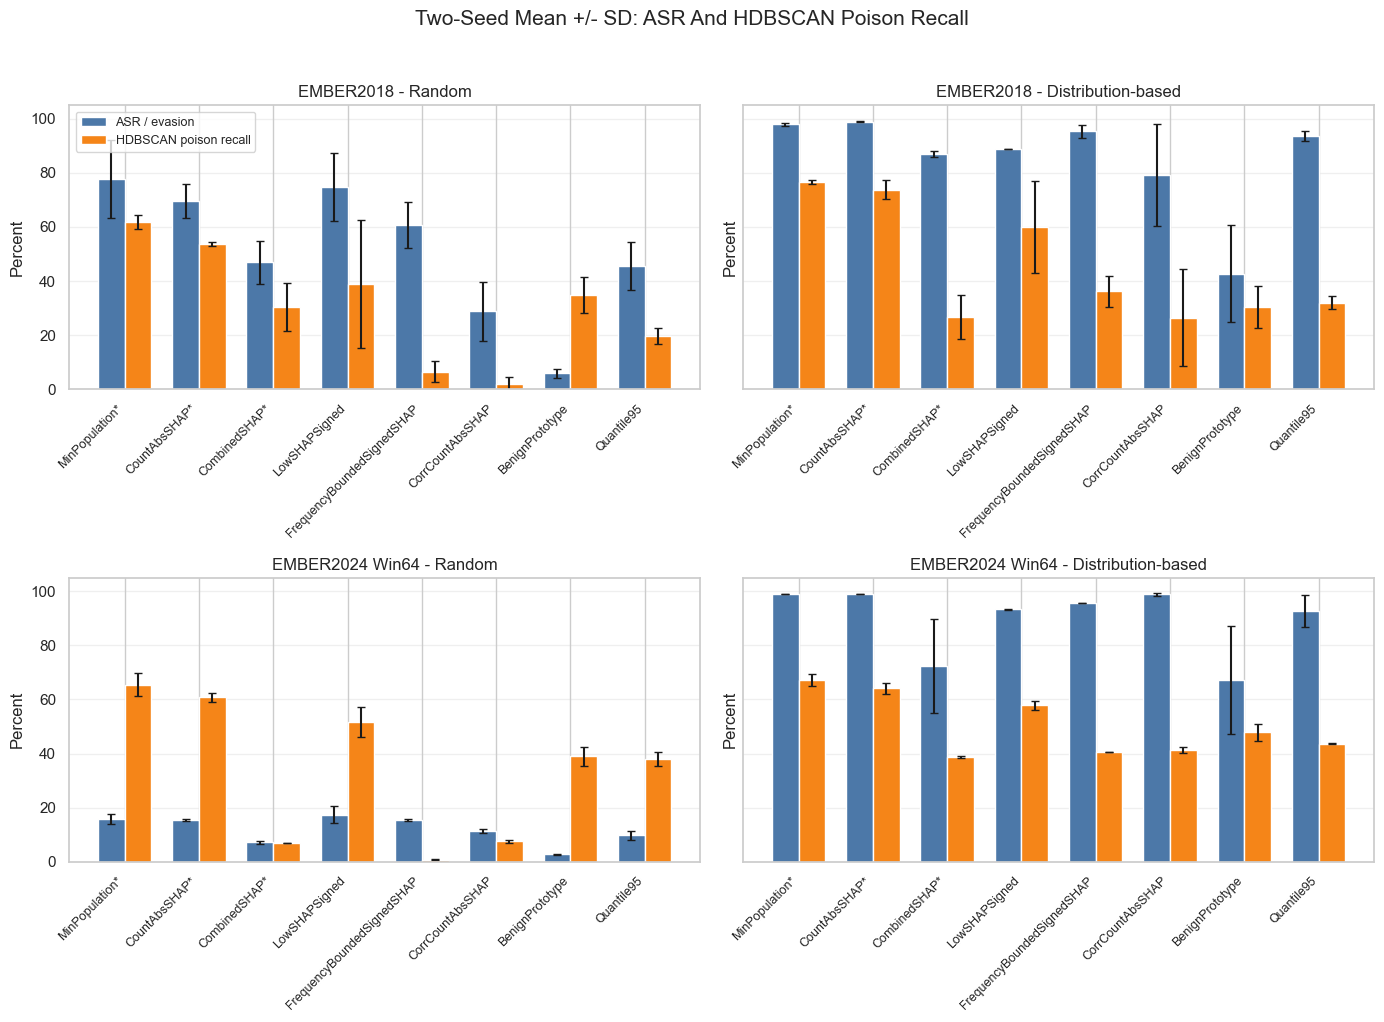

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/plots/final_result/poison_1p_seed_comparison/two_seed_mean_std_asr_hdbscan_bars.png

/Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 1/plots/final_result/poison_1p_seed_comparison/two_seed_mean_std_asr_hdbscan_bars.pdf

In [15]:
bar = mean_std.copy()
bar['display_selector'] = bar['selector']
selector_order_mean = [SEED_SELECTOR_LABELS[s] for s in COMMON_SELECTORS if SEED_SELECTOR_LABELS[s] in set(bar['selector'])]
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
for ax, (dataset, sampling) in zip(axes.flat, [(d, s) for d in ['EMBER2018', 'EMBER2024 Win64'] for s in ['Random', 'Distribution-based']]):
    sub = bar[(bar['dataset'] == dataset) & (bar['sampling'] == sampling)].copy().set_index('selector').reindex(selector_order_mean).reset_index()
    x = np.arange(len(sub)); width = 0.36
    ax.bar(x - width/2, sub['asr_mean'], width, yerr=sub['asr_std'], capsize=3, color='#4C78A8', label='ASR / evasion')
    recall = sub['poison_recall_mean_hdbscan']
    recall_sd = sub['poison_recall_std_hdbscan']
    ax.bar(x + width/2, recall, width, yerr=recall_sd, capsize=3, color='#F58518', label='HDBSCAN poison recall')
    ax.set_title(f'{dataset} - {sampling}')
    ax.set_xticks(x); ax.set_xticklabels(sub['selector'], rotation=45, ha='right', fontsize=9)
    ax.set_ylim(0, 105); ax.set_ylabel('Percent')
    ax.grid(axis='y', alpha=0.3)
axes[0, 0].legend(loc='upper left', fontsize=9)
fig.suptitle('Two-Seed Mean +/- SD: ASR And HDBSCAN Poison Recall', y=1.02, fontsize=15)
fig.tight_layout()
mean_bar_png = SEED_COMPARISON_OUTPUT / 'two_seed_mean_std_asr_hdbscan_bars.png'
mean_bar_pdf = SEED_COMPARISON_OUTPUT / 'two_seed_mean_std_asr_hdbscan_bars.pdf'
fig.savefig(mean_bar_png, dpi=220, bbox_inches='tight'); fig.savefig(mean_bar_pdf, bbox_inches='tight'); plt.show()
display(FileLink(str(mean_bar_png))); display(FileLink(str(mean_bar_pdf)))
